In [8]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Downloading the WeatherBench data

We will use the data at 5.625 degree resolution, equivalent to 32x64 points across the globe - any higher will be too computationally expensive for GPs

Data will be downloaded under the `data/` directory. Set `variable_name` to `geopotential_500` for geopotential data, or `2m_temperature` for temperature data. The data for each variable is several gigabytes in size, so will take a few minutes to download.

More information (e.g. other variables available) can be found at https://www.github.com/pangeo-data/WeatherBench

In [ ]:
variable_name = "2m_temperature"
url = f"https://dataserv.ub.tum.de/s/m1524895/download?path=%2F5.625deg%2F{variable_name}&files={variable_name}_5.625deg.zip"
# !wget "{url}" -O data/{variable_name}.zip
# !unzip data/{variable_name}.zip -d data/5.625deg/{variable_name}
# !rm data/{variable_name}.zip

Archive:  data/2m_temperature.zip
  inflating: data/5.625deg/2m_temperature/2m_temperature_1979_5.625deg.nc  
  inflating: data/5.625deg/2m_temperature/2m_temperature_1980_5.625deg.nc  
  inflating: data/5.625deg/2m_temperature/2m_temperature_1981_5.625deg.nc  
  inflating: data/5.625deg/2m_temperature/2m_temperature_1982_5.625deg.nc  
  inflating: data/5.625deg/2m_temperature/2m_temperature_1983_5.625deg.nc  
  inflating: data/5.625deg/2m_temperature/2m_temperature_1984_5.625deg.nc  
  inflating: data/5.625deg/2m_temperature/2m_temperature_1985_5.625deg.nc  
  inflating: data/5.625deg/2m_temperature/2m_temperature_1986_5.625deg.nc  
  inflating: data/5.625deg/2m_temperature/2m_temperature_1987_5.625deg.nc  
  inflating: data/5.625deg/2m_temperature/2m_temperature_1988_5.625deg.nc  
  inflating: data/5.625deg/2m_temperature/2m_temperature_1989_5.625deg.nc  
  inflating: data/5.625deg/2m_temperature/2m_temperature_1990_5.625deg.nc  
  inflating: data/5.625deg/2m_temperature/2m_temperatu

# Loading and processing

In [ ]:
from src.data_processing import load_xarray, process_xarray

Load the data using the `load_xarray` function.

- The root directory should contain the .nc weather data files
- `var` should be set to `"z"` for geopotential and `"t2m"` for temperature.

In [53]:
geopotential_xarray = load_xarray(root="data/5.625deg/geopotential_500", var="z")

Processing and subsetting the data with `process_xarray`. Each slice has syntax `slice(start, end, step)`. If any are not provided, the entire dimension is used.

Return:
- `t` is a (n_time,) array of time points.
- `x` is a (n_space, 2) array of locations, where each row is a (latitude, longitude) pair.
- `y` is a (n_time, n_space,) array of weather variable values.

In [64]:
time_slice = slice("2017-01-01", "2018-01-01")
latitude_slice = slice(-90, 90)
longitude_slice = slice(0, 360)

t, x, y = process_xarray(
    data_xarray=geopotential_xarray,
    time_slice=time_slice,
    latitude_slice=latitude_slice,
    longitude_slice=longitude_slice,
)
print(f"Time array: {t.shape}")
print(f"Locations array: {x.shape}")
print(f"Variables array: {y.shape}")

Time array: (8784,)
Locations array: (2048, 2)
Variables array: (8784, 2048)


# Normalising the data

In [ ]:
y_mean = np.mean(y, axis=0)
y_std = np.std(y, axis=0)
y_normalised = (y - y_mean) / y_std

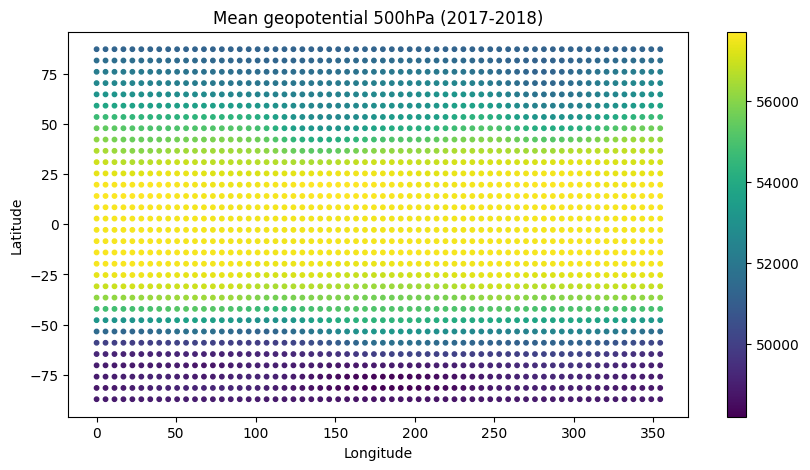

In [73]:
# Plot the mean of the geopotential values at each location in the subset
plt.figure(figsize=(10, 5))
plt.scatter(x[:, 1], x[:, 0], c=y_mean, cmap="viridis", s=10) # x is an array of all the (latitude, longitude) coords
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Mean geopotential 500hPa (2017-2018)");